# Machine learning - Agrégation de modèles

## TP noté - Master SDDP

Raphaël CARRERE & Jean Florencin LAPITRE

On considère le jeu de données ESCAP.csv tiré des résultats de l’enquête ESCAPAD 2017. Cette enquête est présentée aux appelés (environ 40 000 appelés) à la Journée Défense Citoyenneté (JDC). 
Seule une partie des réponses vous est fournie : elle concerne le tronc commun (qui porte sur la situation personnelle des appelés) et le module B (qui porte sur la consommation de boissons alcoolisées).

La variable à prédire est la variable quantitative Q19A, « Age au premier alcool ».

## 0 - Importation des packages et des données

### Installation des packages

In [1]:
pip install s3fs

Note: you may need to restart the kernel to use updated packages.


Chargement des packages utilisés

In [2]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import s3fs
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
from scipy.stats import chi2_contingency
import statsmodels.stats.weightstats as ws
from sklearn.model_selection import train_test_split
import geopandas as gpd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

### Chargement des données

Les données ont été déposées sur S3. Après analyse de l'encodage de la table, on choisit directement de considérer les espaces vides comme des NA. 

In [3]:
MY_BUCKET = "raphcrre"
PATH_ESCAP = f"s3://{MY_BUCKET}/diffusion/projet_apprentissage/ESCAP.csv"

escap = pd.read_csv(PATH_ESCAP, sep=";", decimal=",", na_values=[" ", "  ", ""])
escap


,A01,Q03,Q04,Q04A,Q04B,Q05,Q06A,Q06B,Q08,Q08C,Q09A1,Q09B1,Q10A1,Q10B1,Q19A,B08A,B08B,pm17B
0,10273,1.0,2.0,NaN,NaN,2.0,1.0,2.0,1.0,2.0,1.0,3.0,6.0,8.0,13.0,NaN,NaN,0.429990
1,37216,1.0,1.0,2.0,NaN,1.0,2.0,3.0,1.0,1.0,1.0,1.0,2.0,7.0,14.0,NaN,NaN,0.429990
2,9527,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,11.0,2.0,1.0,0.440840
3,10279,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,14.0,4.0,2.0,0.440840
4,10282,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,6.0,15.0,1.0,1.0,0.440840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13309,6872,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,6.0,17.0,3.0,2.0,2.640086
13310,6891,1.0,1.0,1.0,NaN,1.0,1.0,1.0,2.0,1.0,1.0,1.0,5.0,6.0,16.0,3.0,3.0,2.640086
13311,6878,1.0,1.0,1.0,NaN,1.0,2.0,1.0,1.0,2.0,1.0,2.0,3.0,6.0,15.0,1.0,1.0,2.651554
13312,6907,1.0,1.0,1.0,NaN,2.0,2.0,3.0,1.0,2.0,2.0,1.0,NaN,NaN,16.0,1.0,1.0,2.651554


In [4]:
print("--- Types détectés ---")
print("Q19A  (cible) :", escap["Q19A"].dtype)
print("pm17B (poids) :", escap["pm17B"].dtype)

print("\n--- Aperçu des 5 premières lignes ---")
print(escap[["A01", "Q03", "Q19A", "pm17B"]].head())

--- Types détectés ---
Q19A  (cible) : float64
pm17B (poids) : float64

--- Aperçu des 5 premières lignes ---
     A01  Q03  Q19A    pm17B
0  10273  1.0  13.0  0.42999
1  37216  1.0  14.0  0.42999
2   9527  1.0  11.0  0.44084
3  10279  1.0  14.0  0.44084
4  10282  1.0  15.0  0.44084


### Traitement des données manquantes

In [5]:
escap["Q19A"] = pd.to_numeric(escap["Q19A"], errors="coerce")

def generate_data_summary(data):
    summary_list = []

    for col in data.columns:
        col_series = data[col]
        nb_na = col_series.isna().sum()
        pct_na = (nb_na / len(data)) * 100
        n_unique = col_series.nunique(dropna=False)
        unique_vals = col_series.unique()

        # Distribution / top modalités
        val_counts = col_series.value_counts(dropna=False).head(5).to_dict()

        summary_list.append(
            {
                "Variable": col,
                "Type": str(col_series.dtype),
                "Nb_NA (vrais)": nb_na,
                "%_NA": round(pct_na, 2),
                "Nb_Modalités": n_unique,
                "Valeurs_Uniques": list(unique_vals[:10]),  # 10 premières
                "Top_5_Frequences": val_counts,
            }
        )

    return pd.DataFrame(summary_list)


# Génération du rapport de synthèse
summary_df = generate_data_summary(escap)

# Configuration d'affichage pandas pour tout voir correctement
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

print("=== SUMMARY GÉNÉRAL DES VARIABLES DE LA BASE ESCAP ===")
print(summary_df[["Variable", "Type", "%_NA", "Nb_Modalités", "Top_5_Frequences"]])

=== SUMMARY GÉNÉRAL DES VARIABLES DE LA BASE ESCAP ===
   Variable     Type   %_NA  Nb_Modalités                                                                            Top_5_Frequences
0       A01    int64   0.00         13314                                           {10273: 1, 37216: 1, 9527: 1, 10279: 1, 10282: 1}
1       Q03  float64   0.17             3                                                             {1.0: 6725, 2.0: 6566, nan: 23}
2       Q04  float64  11.89             3                                                           {1.0: 11241, nan: 1583, 2.0: 490}
3      Q04A  float64   4.45             4                                                  {1.0: 11616, 2.0: 952, nan: 593, 3.0: 153}
4      Q04B  float64  95.97             5                                         {nan: 12777, 2.0: 264, 1.0: 139, 4.0: 100, 3.0: 34}
5       Q05  float64   0.30             3                                                             {1.0: 9269, 2.0: 4005, nan: 40}
6      

In [6]:
# Fonction pour afficher la distribution complète d'une variable
def inspect_variable(data, col_name):
    print(f"\n--- Distribution détaillée de : {col_name} ---")
    counts = data[col_name].value_counts(dropna=False).sort_index()
    pct = (
        data[col_name]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        * 100
    )
    df_res = pd.DataFrame({"Effectif": counts, "Pourcentage (%)": pct.round(2)})
    print(df_res)


# Exemple d'inspection sur les variables clés
for col in ["Q19A", "Q04A", "Q08C", "Q09A1", "Q10A1", "B08A"]:
    inspect_variable(escap, col)


--- Distribution détaillée de : Q19A ---
      Effectif  Pourcentage (%)
Q19A                           
0.0          3             0.02
1.0          5             0.04
2.0          7             0.05
3.0         19             0.14
4.0          7             0.05
5.0         15             0.11
6.0         42             0.32
7.0         54             0.41
8.0        110             0.83
9.0         67             0.50
10.0       410             3.08
11.0       177             1.33
12.0       653             4.90
13.0       982             7.38
14.0      2150            16.15
15.0      3244            24.37
16.0      2331            17.51
17.0       568             4.27
18.0        45             0.34
19.0        25             0.19
20.0         1             0.01
25.0         3             0.02
26.0         2             0.02
32.0         1             0.01
NaN       2393            17.97

--- Distribution détaillée de : Q04A ---
      Effectif  Pourcentage (%)
Q04A                

In [7]:
# Afficher les fréquences des âges extrêmes
print("--- Valeurs inférieures à 10 ans ---")
print(escap[escap["Q19A"] < 10]["Q19A"].value_counts().sort_index())

print("\n--- Valeurs supérieures ou égales à 18 ans ---")
print(escap[escap["Q19A"] >= 18]["Q19A"].value_counts().sort_index())

--- Valeurs inférieures à 10 ans ---
Q19A
0.0      3
1.0      5
2.0      7
3.0     19
4.0      7
5.0     15
6.0     42
7.0     54
8.0    110
9.0     67
Name: count, dtype: int64

--- Valeurs supérieures ou égales à 18 ans ---
Q19A
18.0    45
19.0    25
20.0     1
25.0     3
26.0     2
32.0     1
Name: count, dtype: int64


Les valeurs manquantes sont codées par des espaces vides et non par des NA initialement donc on a chargé directement les données en recodant les NA. La variable cible Q19A contient 17,97% de NA ainsi que des valeurs extrêmes à traiter (impossible de boire son premier verre d'alcool après 25 ans sachant que le questionnaire est donné pendant la JDC qui a lieu pour les citoyens entre 16 et 25 ans). 

In [8]:
# 1. Copie de travail
df_clean = escap.copy()

# 2. Filtrage de la cible sur la plage plausible (5 à 20 ans)
df_clean = df_clean[
    df_clean["Q19A"].notna()
    & (df_clean["Q19A"] >= 5)
    & (df_clean["Q19A"] <= 20)
].copy()

# 3. Filtrage des poids valides
df_clean = df_clean[
    df_clean["pm17B"].notna() & (df_clean["pm17B"] > 0)
].copy()

# 4. Traitement des prédicteurs (passage des NaN en catégorie "Manquant")
cols_predicteurs = [
    c for c in df_clean.columns if c not in ["Q19A", "pm17B", "A01"]
]

for col in cols_predicteurs:
    df_clean[col] = (
        df_clean[col].fillna("Manquant").astype(str).astype("category")
    )

# 5. Calcul des statistiques descriptives de la cible (non pondérées et pondérées)
moyenne_brute = df_clean["Q19A"].mean()
moyenne_pond = np.average(df_clean["Q19A"], weights=df_clean["pm17B"])

print("=== BILAN DU NETTOYAGE ===")
print(f"Nombre d'observations initiales  : {len(escap)}")
print(f"Nombre d'observations conservées : {len(df_clean)}")
print(f"Somme des poids de sondage    : {df_clean['pm17B'].sum():.2f}")
print(f"Moyenne brute de Q19A         : {moyenne_brute:.2f} ans")
print(f"Moyenne pondérée de Q19A      : {moyenne_pond:.2f} ans")

=== BILAN DU NETTOYAGE ===
Nombre d'observations initiales  : 13314
Nombre d'observations conservées : 10874
Somme des poids de sondage    : 10836.42
Moyenne brute de Q19A         : 14.33 ans
Moyenne pondérée de Q19A      : 14.32 ans


La base contient 10 874 observations exploitables avec une somme des poids de sondage cohérente. 

## 1 - Statistique descriptive de la table

### Analyse de la variable d'âge au premier alcool (variable cible)

In [9]:
# Dictionnaire des libellés principaux pour la lisibilité
labels_dict = {
    "Q03": "Sexe",
    "B08A": "Consommation Père Alcool",
    "B08B": "Consommation Mère Alcool",
    "Q04": "Situation Études",
    "Q05": "Redoublement",
    "Q10A1": "PCS Père",
    "Q10B1": "PCS Mère",
}

variables_a_traiter = ["Q19A", "Q03", "B08A", "B08B", "Q04", "Q05", "Q10A1", "Q10B1"]
lignes_tableau = []

# Somme totale des poids pour le calcul des proportions pondérées
somme_poids_totale = df_clean["pm17B"].sum()

for var in variables_a_traiter:
    nom_var = labels_dict.get(var, var)

    # Regroupement par modalité
    for mod, group in df_clean.groupby(var, observed=False):
        n_brut = len(group)
        poids_mod = group["pm17B"].sum()
        prop_pond = (poids_mod / somme_poids_totale) * 100

        lignes_tableau.append(
            {
                "Variable": nom_var,
                "Modalité": str(mod),
                "Effectif brut (N)": n_brut,
                "Proportion pondérée (%)": round(prop_pond, 2),
            }
        )

# Création du DataFrame récapitulatif
df_freq = pd.DataFrame(lignes_tableau)

# Affichage par variable
for var_label in df_freq["Variable"].unique():
    print(f"\n=== Distribution : {var_label} ===")
    sous_table = df_freq[df_freq["Variable"] == var_label][
        ["Modalité", "Effectif brut (N)", "Proportion pondérée (%)"]
    ]
    print(sous_table.to_string(index=False))


=== Distribution : Q19A ===


Modalité  Effectif brut (N)  Proportion pondérée (%)
     5.0                 15                     0.15
     6.0                 42                     0.42
     7.0                 54                     0.51
     8.0                110                     1.07
     9.0                 67                     0.62
    10.0                410                     3.78
    11.0                177                     1.63
    12.0                653                     5.99
    13.0                982                     8.96
    14.0               2150                    19.86
    15.0               3244                    29.93
    16.0               2331                    21.28
    17.0                568                     5.14
    18.0                 45                     0.41
    19.0                 25                     0.24
    20.0                  1                     0.01

=== Distribution : Sexe ===


Modalité  Effectif brut (N)  Proportion pondérée (%)
     1.0               5521                    51.38
     2.0               5340                    48.48
Manquant                 13                     0.14

=== Distribution : Consommation Père Alcool ===
Modalité  Effectif brut (N)  Proportion pondérée (%)
     1.0               1613                    14.83
     2.0               1873                    17.18
     3.0               1825                    16.71
     4.0               2654                    24.54
     5.0               1785                    16.55
Manquant               1124                    10.19

=== Distribution : Consommation Mère Alcool ===
Modalité  Effectif brut (N)  Proportion pondérée (%)
     1.0               2638                    24.21
     2.0               2435                    22.47
     3.0               1861                    17.10
     4.0               2205                    20.32
     5.0                883                     8.15
M

Ces premiers tableaux nous fournissent déjà un bel aperçu de la base de données. 

Il y a une concentration forte de l'âge au premier verre (Q19A) entre 14 et 16 ans : près de 71 % des jeunes déclarent avoir bu leur premier verre entre 14 et 16 ans (avec un mode à 15 ans représentant 29,9 % de l'échantillon). Les initiations précoces représentent plus de 8 % des répondants (11 ans et moins) et les initiations tardives sont rares (plus de 18 ans : < 1%). Cela reste normal avec une population répondante jeune au moment de la JDC (souvent moins de 18 ans). 

Pour la modélisation cela implique que la distribution est relativement resserrée avec une faible variance. Un modèle qui prédit constamment autour de 14-15 ans aura un faible écart moyen (MAE/RMSE), il faudra donc analyser attentivement les erreurs sur les valeurs extrêmes.

Au niveau de la consommation des parents (B08A & B08B), on retrouve un biais paternel : 16,55 % consomment de l'alcool presque chaque jour (modalité 5) et 24,54 % au moins une fois par semaine (modalité 4). Au total, plus de 41 % des pères consomment régulièrement à la maison. En revanche, la consommation quotidienne de la mère est deux fois plus faible (8,15%) et 24,21% ne boivent jamais. Il y a beaucoup de données manquantes (8%), expliquées probablement par les foyers monoparentaux.


84,76 % des jeunes suivent encore des études et 28,25% déclarent avoir déjà redoublé. 


In [10]:
def weighted_quantile(values, quantiles, sample_weight=None):
    """Calcule des quantiles pondérés précis."""
    values = np.array(values)
    quantiles = np.array(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.array(sample_weight)
    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]
    weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
    weighted_quantiles /= np.sum(sample_weight)
    return np.interp(quantiles, weighted_quantiles, values)


# Calculs des indicateurs pondérés
q25, q50, q75 = weighted_quantile(
    df_clean["Q19A"], [0.25, 0.50, 0.75], sample_weight=df_clean["pm17B"]
)
descr = ws.DescrStatsW(df_clean["Q19A"], weights=df_clean["pm17B"])

print("=== BILAN DESCRIPTIF DE LA CIBLE Q19A (PONDÉRÉ) ===")
print(f"Moyenne pondérée    : {descr.mean:.2f} ans")
print(f"Écart-type pondéré  : {descr.std:.2f} ans")
print(
    f"Médiane pondérée    : {q50:.2f} ans"
)  # Crucial : si moyenne < médiane -> asymétrie à gauche
print(f"Intervalle Q1 - Q3  : [{q25:.1f} ans ; {q75:.1f} ans]")
print(f"Écart interquartile : {q75 - q25:.1f} ans")

=== BILAN DESCRIPTIF DE LA CIBLE Q19A (PONDÉRÉ) ===
Moyenne pondérée    : 14.32 ans
Écart-type pondéré  : 1.97 ans
Médiane pondérée    : 15.00 ans
Intervalle Q1 - Q3  : [14.0 ans ; 16.0 ans]
Écart interquartile : 2.0 ans


### Analyse bivariée

In [11]:
bivariate_results = []

for col in cols_predicteurs:
    # 1. Moyennes pondérées de Q19A pour chaque modalité du prédicteur
    means_by_cat = df_clean.groupby(col, observed=False).apply(
        lambda g: (
            np.average(g["Q19A"], weights=g["pm17B"]) if len(g) > 0 else np.nan
        )
    )

    # 2. Test statistique de Kruskal-Wallis
    groups = [
        group["Q19A"].values
        for _, group in df_clean.groupby(col, observed=False)
        if len(group) > 0
    ]
    stat, p_val = stats.kruskal(*groups)

    bivariate_results.append(
        {
            "Variable": col,
            "p-value": f"{p_val:.2e}",
            "Significatif (<0.05)": "Oui" if p_val < 0.05 else "Non",
            "Moyennes par catégorie": dict(means_by_cat.round(2)),
        }
    )

df_biv = pd.DataFrame(bivariate_results)

print("=== STATISTIQUES BIVARIÉES : LIEN AVEC L'ÂGE AU 1ER VERRE ===")
print(df_biv[["Variable", "p-value", "Significatif (<0.05)"]])

=== STATISTIQUES BIVARIÉES : LIEN AVEC L'ÂGE AU 1ER VERRE ===
   Variable   p-value Significatif (<0.05)
0       Q03  2.57e-29                  Oui
1       Q04  2.72e-05                  Oui
2      Q04A  5.26e-02                  Non
3      Q04B  1.56e-02                  Oui
4       Q05  9.01e-22                  Oui
5      Q06A  1.95e-07                  Oui
6      Q06B  3.73e-07                  Oui
7       Q08  2.21e-03                  Oui
8      Q08C  4.71e-01                  Non
9     Q09A1  1.10e-03                  Oui
10    Q09B1  8.11e-06                  Oui
11    Q10A1  1.39e-30                  Oui
12    Q10B1  6.07e-28                  Oui
13     B08A  2.63e-47                  Oui
14     B08B  1.01e-48                  Oui


Quasiment toutes les variables sont significativement liées à l'âge au premier verre par le test de Kruskal-Wallis (p <0.05). Les p-values sur les variables de consommation des parents (B08A et B08B) sont très significatives. Le sexe (Q03) et la PCS des parents (Q10A1 et Q10B1) sont également très significatives. En revanche, deux variables ne sont pas significatives : Q04A qui correspond à la situation scolaire et Q08C qui correspond à la vie des parents. Ces tests de Kruskal-Wallis ne s'appuient pas sur les pondérations. C'est pourquoi nous effectuons également une ANOVA pondérée. 

In [12]:
results_anova = []

for col in cols_predicteurs:
    # Modèle linéaire avec poids de sondage
    model = smf.wls(f"Q19A ~ C({col})", data=df_clean, weights=df_clean["pm17B"]).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_val = anova_table.loc[f"C({col})", "PR(>F)"]
    f_stat = anova_table.loc[f"C({col})", "F"]

    results_anova.append(
        {
            "Variable": col,
            "F-Stat": round(f_stat, 2),
            "p-value (ANOVA pondérée)": f"{p_val:.2e}",
            "Significatif": "Oui" if p_val < 0.05 else "Non",
        }
    )

df_anova = pd.DataFrame(results_anova).sort_values(by="F-Stat", ascending=False)
print("=== TESTS D'EFFET GLOBAL PONDÉRÉS (ANOVA WLS) ===")
print(df_anova.to_string(index=False))

=== TESTS D'EFFET GLOBAL PONDÉRÉS (ANOVA WLS) ===
Variable  F-Stat p-value (ANOVA pondérée) Significatif
     Q03   72.56                 4.96e-32          Oui
    B08A   41.81                 8.57e-43          Oui
    B08B   39.43                 2.70e-40          Oui
     Q05   35.73                 3.43e-16          Oui
   Q10A1   16.76                 9.59e-28          Oui
   Q10B1   13.83                 2.23e-22          Oui
     Q04   13.07                 2.14e-06          Oui
    Q06B    9.05                 5.59e-06          Oui
    Q06A    8.87                 7.24e-06          Oui
    Q04A    4.72                 2.72e-03          Oui
   Q09B1    3.23                 1.98e-03          Oui
     Q08    3.18                 7.16e-03          Oui
    Q04B    2.83                 2.34e-02          Oui
   Q09A1    2.03                 4.79e-02          Oui
    Q08C    0.75                 5.89e-01          Non


L'analyse de variance à moindres carrés pondérés (WLS) valide l'influence de la quasi-totalité des prédicteurs socio-démographiques et familiaux sur l'âge de première consommation d'alcool (Q19A).

Sur les 15 prédicteurs testés avec la pondération, 14 variables présentent un effet global significatif au seuil alpha = 5 % (p < 0,05).   Seule la variable Q08C ("Vie des parents", F = 0,75, p = 0,589) n'est pas significative.

La statistique F de Snedecor mesure l'intensité de la variance inter-groupes expliquée par rapport à la variance intra-groupe résiduelle. 


On peut voir que le Sexe est le facteur explicatif le plus discriminant (F > 30). La consommation des parents constitue également un prédicteur important de la variable cible (F > 30). Vient ensuite le parcours scolaire avec la variable de redoublement. Il y a aussi les variables d'origine sociale avec les PCS des parents qui influencent significativement l'âge au premier alcool. Ces variables ont une valeur de F entre 10 et 20. 

Les facteurs suivants ont un effet plus modéré mais bien présent (2 < F < 10): situations scolaire et professionnelle, difficultés scolaires, situation d'activité des parents. 

Le statut marital des parents n'est pas significatif. 

Ces résultats impliquent que la variable de vie des parents peut être écartée (ou laissée aux arbres qui l'écarteront naturellement). L'ANOVA montre que la question Q04 absorbe les questions Q04A et Q04B. Enfin, on s'attend à ce que le Sexe, la consommation des parents et le redoublement soient des variables importantes dans nos modèles. 

In [13]:
def afficher_detail_variable(col_name):
    row = df_biv[df_biv["Variable"] == col_name].iloc[0]
    print(f"\n--- Détail pour {col_name} ---")
    print(f"p-value : {row['p-value']}")
    print("Âge moyen pondéré par catégorie :")
    for cat, val in row["Moyennes par catégorie"].items():
        print(f"  Modalité {cat} : {val} ans")


# Exemple sur le Sexe (Q03) et la consommation du Père (B08A)
afficher_detail_variable("Q03")
afficher_detail_variable("B08A")
afficher_detail_variable("B08B")


--- Détail pour Q03 ---
p-value : 2.57e-29
Âge moyen pondéré par catégorie :
  Modalité 1.0 : 14.1 ans
  Modalité 2.0 : 14.55 ans
  Modalité Manquant : 13.93 ans

--- Détail pour B08A ---
p-value : 2.63e-47
Âge moyen pondéré par catégorie :
  Modalité 1.0 : 14.74 ans
  Modalité 2.0 : 14.61 ans
  Modalité 3.0 : 14.34 ans
  Modalité 4.0 : 14.16 ans
  Modalité 5.0 : 13.94 ans
  Modalité Manquant : 14.19 ans

--- Détail pour B08B ---
p-value : 1.01e-48
Âge moyen pondéré par catégorie :
  Modalité 1.0 : 14.68 ans
  Modalité 2.0 : 14.45 ans
  Modalité 3.0 : 14.26 ans
  Modalité 4.0 : 14.08 ans
  Modalité 5.0 : 13.83 ans
  Modalité Manquant : 14.13 ans


On remarque une différence dans l'âge moyen pondéré au premier verre entre les sexes avec les hommes qui boivent en moyenne plus tôt que les femmes (14,1 ans contre 14,55 ans). Le fait que le père (B08A) et/ou la mère (B08B) consomment de l'alcool régulièrement diminue l'âge du premier verre d'alcool (0.8 ans de différence en moyenne pondérée entre une consommation quotidienne et une consommation nulle des parents. 

Boxplots de l'âge au premier alcool en fonction du sexe et de la consommation des parents

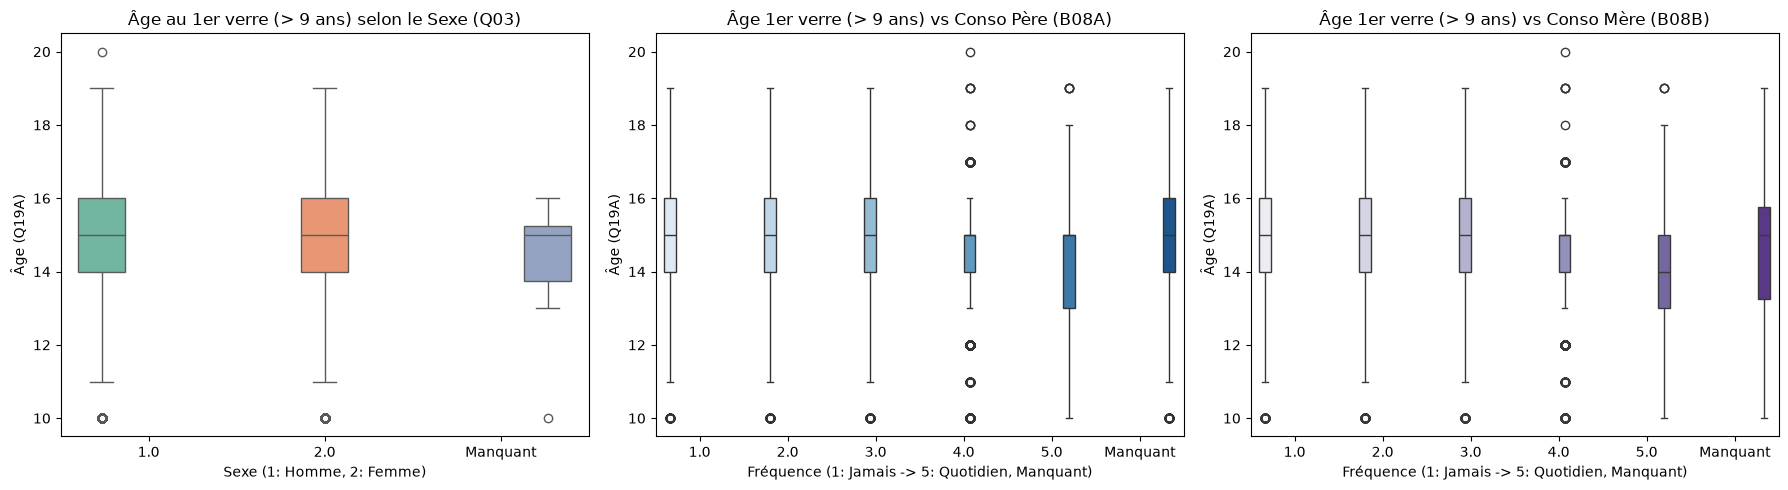

In [14]:
# Création du sous-ensemble filtré (âge > 9 ans) pour la lisibilité des boxplots
df_filtered = df_clean[df_clean["Q19A"] > 9]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Âge 1er verre vs Sexe (Q03)
sns.boxplot(
    data=df_filtered,
    x="Q03",
    y="Q19A",
    ax=axes[0],
    palette="Set2",
    hue="Q03",
    legend=False,
)
axes[0].set_title("Âge au 1er verre (> 9 ans) selon le Sexe (Q03)")
axes[0].set_xlabel("Sexe (1: Homme, 2: Femme)")
axes[0].set_ylabel("Âge (Q19A)")

# 2. Âge 1er verre vs Conso Père (B08A)
sns.boxplot(
    data=df_filtered,
    x="B08A",
    y="Q19A",
    ax=axes[1],
    palette="Blues",
    hue="B08A",
    legend=False,
)
axes[1].set_title("Âge 1er verre (> 9 ans) vs Conso Père (B08A)")
axes[1].set_xlabel("Fréquence (1: Jamais -> 5: Quotidien, Manquant)")
axes[1].set_ylabel("Âge (Q19A)")

# 3. Âge 1er verre vs Conso Mère (B08B)
sns.boxplot(
    data=df_filtered,
    x="B08B",
    y="Q19A",
    ax=axes[2],
    palette="Purples",
    hue="B08B",
    legend=False,
)
axes[2].set_title("Âge 1er verre (> 9 ans) vs Conso Mère (B08B)")
axes[2].set_xlabel("Fréquence (1: Jamais -> 5: Quotidien, Manquant)")
axes[2].set_ylabel("Âge (Q19A)")

plt.tight_layout()
plt.show()

Graphique de l'âge au premier alcool selon le sexe

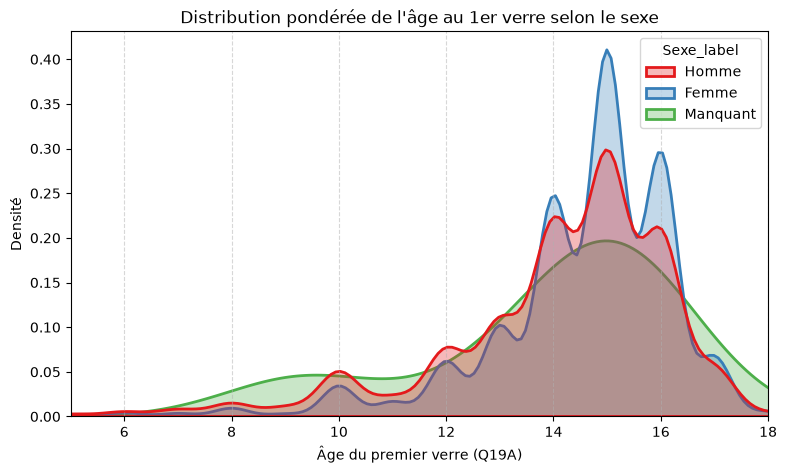

In [15]:
# Dictionnaire pour un affichage lisible de Q03
sexe_map = {"1.0": "Homme", "2.0": "Femme", "1": "Homme", "2": "Femme"}
df_clean["Sexe_label"] = df_clean["Q03"].astype(str).map(sexe_map).fillna(df_clean["Q03"])

plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=df_clean,
    x="Q19A",
    hue="Sexe_label",
    weights="pm17B",  # Prise en compte du poids de sondage
    common_norm=False,
    fill=True,
    alpha=0.3,
    linewidth=2,
    palette="Set1",
)

plt.title("Distribution pondérée de l'âge au 1er verre selon le sexe")
plt.xlabel("Âge du premier verre (Q19A)")
plt.ylabel("Densité")
plt.xlim(5, 18)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

### Analyse des prédicteurs

In [16]:
def cramers_v(var1, var2):
    """Calcule le V de Cramér entre deux variables catégorielles."""
    contingency_tab = pd.crosstab(var1, var2)
    chi2 = chi2_contingency(contingency_tab)[0]
    n = contingency_tab.sum().sum()
    r, k = contingency_tab.shape
    if min(r - 1, k - 1) == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))


# Calcul croisé sur l'ensemble des prédicteurs
cramer_results = []

for col1, col2 in itertools.combinations(cols_predicteurs, 2):
    contingency_tab = pd.crosstab(df_clean[col1], df_clean[col2])
    chi2, p_val, dof, _ = chi2_contingency(contingency_tab)
    v = cramers_v(df_clean[col1], df_clean[col2])

    cramer_results.append(
        {
            "Variable 1": col1,
            "Variable 2": col2,
            "Chi2": round(chi2, 2),
            "p-value": f"{p_val:.2e}",
            "V de Cramér": round(v, 3),
        }
    )

df_cramer = pd.DataFrame(cramer_results).sort_values(
    by="V de Cramér", ascending=False
)

print("=== TOP 10 DES LIAISONS LES PLUS FORTES ENTRE PRÉDICTEURS ===")
print(df_cramer.head(10).to_string(index=False))

=== TOP 10 DES LIAISONS LES PLUS FORTES ENTRE PRÉDICTEURS ===
Variable 1 Variable 2     Chi2  p-value  V de Cramér
       Q04       Q04A  9109.92 0.00e+00        0.647
       Q04       Q04B  8828.30 0.00e+00        0.637
      Q04A       Q04B  9319.43 0.00e+00        0.534
      B08A       B08B 14749.68 0.00e+00        0.521
     Q09A1      Q10A1 13269.46 0.00e+00        0.418
     Q09B1      Q10B1 11776.66 0.00e+00        0.393
      Q06A       Q06B  4125.61 0.00e+00        0.356
     Q10A1      Q10B1  8558.01 0.00e+00        0.296
      Q08C      Q09A1  4272.80 0.00e+00        0.280
      Q08C      Q10A1  3006.69 0.00e+00        0.235


La situation scolaire et le parcours professionnel sont très corrélés, de même que la consommation de chacun des parents ou encore la situation professionnelle et la PCS des deux parents. Les difficultés scolaires se recoupent aussi fortement. 

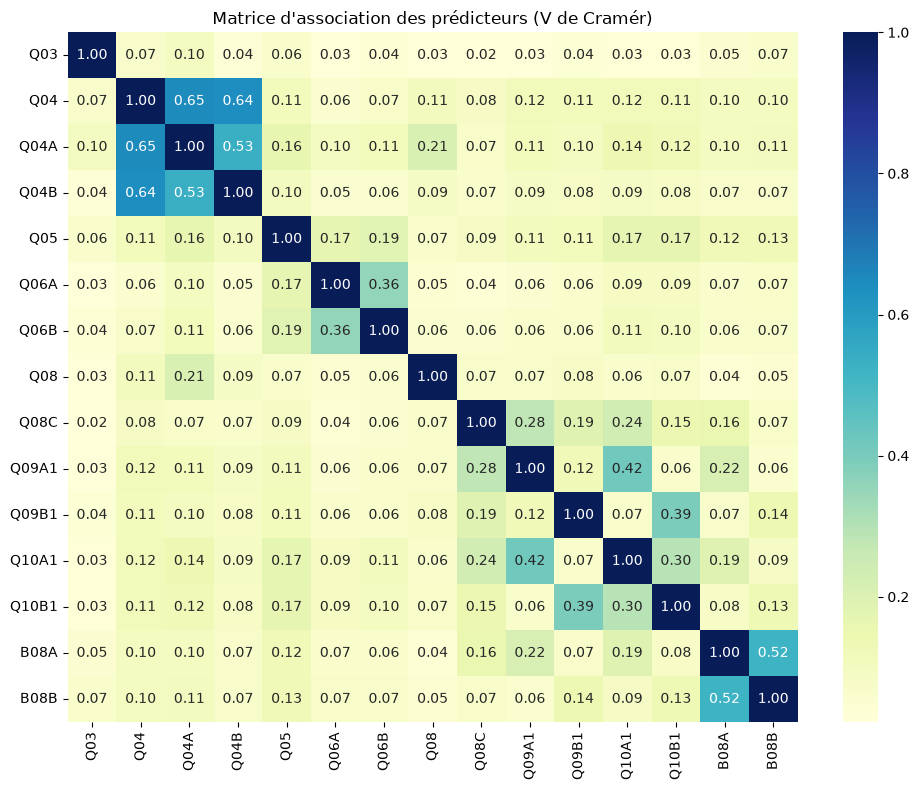

In [17]:
# Construction de la matrice carrée des V de Cramér
matrix_v = pd.DataFrame(
    index=cols_predicteurs, columns=cols_predicteurs, dtype=float
)

for c1 in cols_predicteurs:
    for c2 in cols_predicteurs:
        if c1 == c2:
            matrix_v.loc[c1, c2] = 1.0
        else:
            matrix_v.loc[c1, c2] = cramers_v(df_clean[c1], df_clean[c2])

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_v, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Matrice d'association des prédicteurs (V de Cramér)")
plt.tight_layout()
plt.show()

## 2 - Modélisation et agrégation

Préparation des modélisations 

In [18]:
# 1. Sélection des prédicteurs (on retire Q19A, pm17B, A01 et la colonne temporaire Sexe_label)
X_cols = [
    col
    for col in df_clean.columns
    if col not in ["Q19A", "pm17B", "A01", "Sexe_label", "Q08C"]
]  # On écarte Q08C car non significative

X_raw = df_clean[X_cols]
y = df_clean["Q19A"]
weights = df_clean["pm17B"]

# 2. Dummification (One-Hot Encoding)
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=int)

# 3. Découpage Train / Test (80% / 20%)
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_encoded, y, weights, test_size=0.20, random_state=42
)

print("=== BILAN DE LA PRÉPARATION DES DONNÉES ===")
print(
    f"Nombre d'observations d'entraînement (Train) : {X_train.shape[0]} (poids total : {w_train.sum():.2f})"
)
print(
    f"Nombre d'observations de test (Test)         : {X_test.shape[0]} (poids total : {w_test.sum():.2f})"
)
print(f"Nombre total de variables encodées (p)       : {X_train.shape[1]}")

=== BILAN DE LA PRÉPARATION DES DONNÉES ===
Nombre d'observations d'entraînement (Train) : 8699 (poids total : 8666.54)
Nombre d'observations de test (Test)         : 2175 (poids total : 2169.88)
Nombre total de variables encodées (p)       : 66


In [19]:
# Dictionnaire global pour stocker les résultats et les prédictions
comparatif_modeles = {}
predictions_test = {}


def calculer_indicateurs(
    model, X_tr, y_tr, w_tr, X_te, y_te, w_te, nom_modele
):
    """Calcule et affiche les indicateurs statistiques d'un modèle (Train vs Test)."""
    # Prédictions
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    # Sauvegarde des prédictions test pour le Stacking ultérieur
    predictions_test[nom_modele] = y_pred_te

    # Calculs des métriques pondérées - Train
    rmse_tr = np.sqrt(
        mean_squared_error(y_tr, y_pred_tr, sample_weight=w_tr)
    )
    mae_tr = mean_absolute_error(y_tr, y_pred_tr, sample_weight=w_tr)
    r2_tr = r2_score(y_tr, y_pred_tr, sample_weight=w_tr)

    # Calculs des métriques pondérées - Test
    rmse_te = np.sqrt(
        mean_squared_error(y_te, y_pred_te, sample_weight=w_te)
    )
    mae_te = mean_absolute_error(y_te, y_pred_te, sample_weight=w_te)
    r2_te = r2_score(y_te, y_pred_te, sample_weight=w_te)

    # Stockage
    res = {
        "Modèle": nom_modele,
        "RMSE Train": round(rmse_tr, 4),
        "RMSE Test": round(rmse_te, 4),
        "Écart RMSE (Overfit)": round(rmse_te - rmse_tr, 4),
        "MAE Test": round(mae_te, 4),
        "R2 Test (%)": round(r2_te * 100, 2),
    }

    comparatif_modeles[nom_modele] = res

    print(f"=== INDICATEURS : {nom_modele.upper()} ===")
    print(
        f"  • RMSE Train : {rmse_tr:.4f} ans | RMSE Test : {rmse_te:.4f} ans"
    )
    print(f"  • Écart Overfitting (Test - Train) : {rmse_te - rmse_tr:.4f} ans")
    print(f"  • MAE Test  : {mae_te:.4f} ans")
    print(f"  • R² Test   : {r2_te * 100:.2f} % de variance expliquée\n")

    return res

### Modèle de référence - Régression Ridge pondérée

Avant de tester des forêts d'arbres, nous mettons en place un modèle linéaire régularisé simple pour savoir si les algorithmes d'ensemble apportent un vrai gain.

In [20]:
# 1. Instanciation et entraînement
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_ridge = calculer_indicateurs(
    ridge_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "1. Baseline (Ridge)",
)

=== INDICATEURS : 1. BASELINE (RIDGE) ===
  • RMSE Train : 1.8927 ans | RMSE Test : 2.0048 ans
  • Écart Overfitting (Test - Train) : 0.1120 ans
  • MAE Test  : 1.4468 ans
  • R² Test   : 3.59 % de variance expliquée



### Modèle de Bagging (Arbres)

Tirage bootstrap d'individus avec arbres complets sans sélection aléatoire de variables à chaque nœud.

In [21]:
# 1. Instanciation et entraînement
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
bagging_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_bagging = calculer_indicateurs(
    bagging_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "2. Bagging",
)

=== INDICATEURS : 2. BAGGING ===
  • RMSE Train : 1.7133 ans | RMSE Test : 2.0279 ans
  • Écart Overfitting (Test - Train) : 0.3146 ans
  • MAE Test  : 1.4644 ans
  • R² Test   : 1.35 % de variance expliquée



### Modèle de Random Forest

Sélection aléatoire d'un sous-ensemble de variables à chaque nœud d'arbre.

In [22]:
# 1. Instanciation et entraînement
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    max_features="sqrt",  # Clé de la RF : sous-ensemble aléatoire de variables
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_rf = calculer_indicateurs(
    rf_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "3. Random Forest",
)

=== INDICATEURS : 3. RANDOM FOREST ===
  • RMSE Train : 1.8030 ans | RMSE Test : 2.0131 ans
  • Écart Overfitting (Test - Train) : 0.2101 ans
  • MAE Test  : 1.4527 ans
  • R² Test   : 2.79 % de variance expliquée



### Modèle de Gradient boosting

Le Boosting construit des arbres séquentiellement pour corriger les erreurs des arbres précédents. 

In [23]:
# 1. Instanciation et entraînement
gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
)
gb_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_gb = calculer_indicateurs(
    gb_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "4. Gradient Boosting",
)

=== INDICATEURS : 4. GRADIENT BOOSTING ===
  • RMSE Train : 1.8335 ans | RMSE Test : 2.0169 ans
  • Écart Overfitting (Test - Train) : 0.1833 ans
  • MAE Test  : 1.4552 ans
  • R² Test   : 2.42 % de variance expliquée



### Modèle de stacking

Le Stacking combine les prédictions des modèles précédents (Bagging, RF, Boosting) en utilisant un régresseur Ridge pour trouver la meilleure pondération globale. 

In [24]:
# 1. Définition des estimateurs de base
estimators = [
    (
        "bagging",
        BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "gb",
        GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
        ),
    ),
]

# 2. Instanciation du Stacking avec un méta-modèle Ridge
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1,
)
stacking_model.fit(X_train, y_train, sample_weight=w_train)

# 3. Calcul et affichage des indicateurs
res_stacking = calculer_indicateurs(
    stacking_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "5. Stacking (Méta-Modèle)",
)

=== INDICATEURS : 5. STACKING (MÉTA-MODÈLE) ===
  • RMSE Train : 1.7937 ans | RMSE Test : 2.0135 ans
  • Écart Overfitting (Test - Train) : 0.2198 ans
  • MAE Test  : 1.4534 ans
  • R² Test   : 2.75 % de variance expliquée



## 3 - Evaluations et comparaisons des modèles

### Comparaison des performances à l'aide du jeu de test

On ajoute un modèle naïf qui prédit toujours la moyenne pondérée de l'âge au premier verre calculée sur le jeu d'entraînement. Il sert de plancher : un modèle utile doit faire mieux que lui.

In [25]:
# Modèle naïf : prédiction constante égale à la moyenne pondérée du train
moyenne_train = np.average(y_train, weights=w_train)
y_pred_naif = np.full(len(y_test), moyenne_train)
predictions_test["0. Naïf (moyenne)"] = y_pred_naif

rmse_naif = np.sqrt(mean_squared_error(y_test, y_pred_naif, sample_weight=w_test))
rmse_naif_tr = np.sqrt(
    mean_squared_error(
        y_train, np.full(len(y_train), moyenne_train), sample_weight=w_train
    )
)
comparatif_modeles["0. Naïf (moyenne)"] = {
    "Modèle": "0. Naïf (moyenne)",
    "RMSE Train": round(rmse_naif_tr, 4),
    "RMSE Test": round(rmse_naif, 4),
    "Écart RMSE (Overfit)": round(rmse_naif - rmse_naif_tr, 4),
    "MAE Test": round(mean_absolute_error(y_test, y_pred_naif, sample_weight=w_test), 4),
    "R2 Test (%)": round(r2_score(y_test, y_pred_naif, sample_weight=w_test) * 100, 2),
}

# Tableau comparatif trié par RMSE test croissante
df_comparatif = (
    pd.DataFrame(comparatif_modeles.values())
    .set_index("Modèle")
    .sort_values("RMSE Test")
)
df_comparatif["Gain RMSE vs naïf (%)"] = (
    (rmse_naif - df_comparatif["RMSE Test"]) / rmse_naif * 100
).round(2)

print("=== COMPARAISON DES MODÈLES SUR LE JEU DE TEST (MÉTRIQUES PONDÉRÉES) ===")
print(df_comparatif.to_string())

=== COMPARAISON DES MODÈLES SUR LE JEU DE TEST (MÉTRIQUES PONDÉRÉES) ===
                           RMSE Train  RMSE Test  Écart RMSE (Overfit)  MAE Test  R2 Test (%)  Gain RMSE vs naïf (%)
Modèle                                                                                                              
1. Baseline (Ridge)            1.8927     2.0048                0.1120    1.4468         3.59                   1.86
3. Random Forest               1.8030     2.0131                0.2101    1.4527         2.79                   1.45
5. Stacking (Méta-Modèle)      1.7937     2.0135                0.2198    1.4534         2.75                   1.43
4. Gradient Boosting           1.8335     2.0169                0.1833    1.4552         2.42                   1.26
2. Bagging                     1.7133     2.0279                0.3146    1.4644         1.35                   0.73
0. Naïf (moyenne)              1.9565     2.0427                0.0862    1.4869        -0.10               

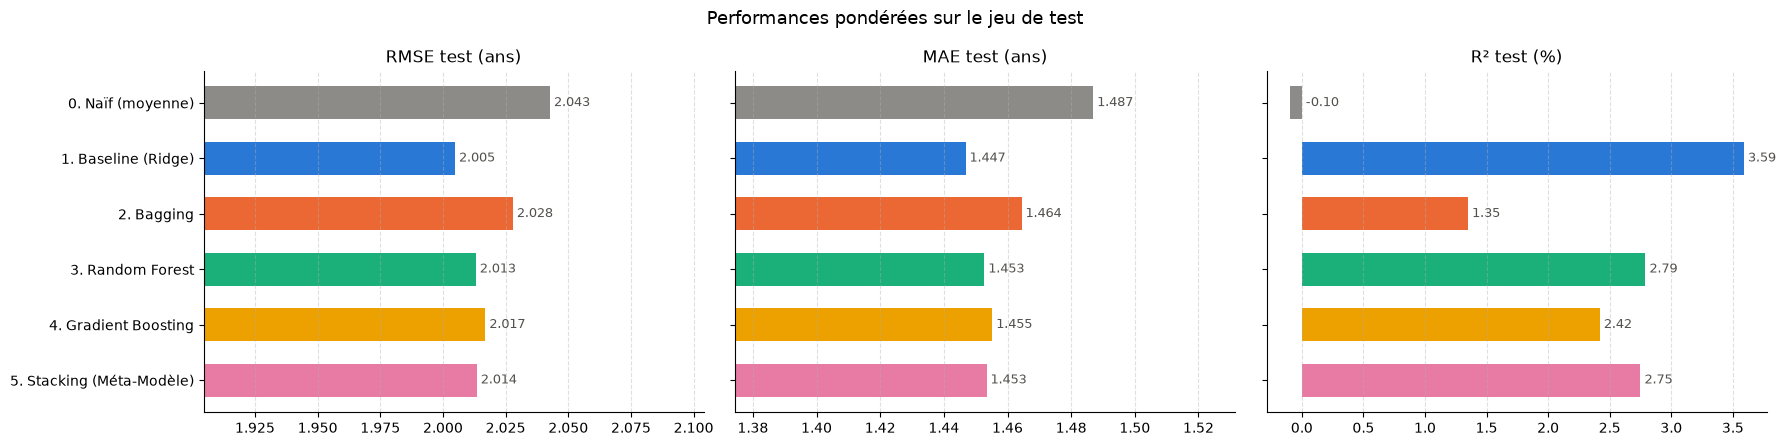

In [26]:
# Ordre et couleurs fixes par modèle (une couleur = un modèle dans tous les graphiques)
ordre_modeles = [
    "0. Naïf (moyenne)",
    "1. Baseline (Ridge)",
    "2. Bagging",
    "3. Random Forest",
    "4. Gradient Boosting",
    "5. Stacking (Méta-Modèle)",
]
couleurs_modeles = dict(
    zip(ordre_modeles, ["#8c8b87", "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
metriques = [
    ("RMSE Test", "RMSE test (ans)"),
    ("MAE Test", "MAE test (ans)"),
    ("R2 Test (%)", "R² test (%)"),
]
for ax, (col, titre) in zip(axes, metriques):
    valeurs = df_comparatif.loc[ordre_modeles, col]
    ax.barh(
        ordre_modeles,
        valeurs,
        color=[couleurs_modeles[m] for m in ordre_modeles],
        height=0.6,
    )
    fmt = ".2f" if col == "R2 Test (%)" else ".3f"
    for i, v in enumerate(valeurs):
        ax.text(max(v, 0), i, f" {v:{fmt}}", va="center", fontsize=9, color="#52514e")
    ax.set_title(titre)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    if col != "R2 Test (%)":
        # Zoom sur la zone utile : les écarts entre modèles sont faibles
        ax.set_xlim(valeurs.min() * 0.95, valeurs.max() * 1.03)
axes[0].invert_yaxis()
plt.suptitle("Performances pondérées sur le jeu de test", fontsize=13)
plt.tight_layout()
plt.show()

Les écarts de performance entre les modèles sont très faibles : le RMSE test va de 2,005 à 2,028 ans, soit moins de 0,03 an d'écart (une dizaine de jours).

- Aucun modèle d'agrégation ne fait mieux que la régression Ridge, qui obtient le meilleur RMSE (2,005 ans), la meilleure MAE (1,447 an) et le meilleur R² (3,6 %).
- Le gain par rapport au modèle naïf est minime : au mieux 1,9 % de RMSE en moins. Avec un R² inférieur à 4 %, les variables disponibles expliquent très peu la variance de l'âge au premier verre.
- Le Bagging est le moins bon modèle et celui qui surapprend le plus (écart train/test de 0,31 an). Les arbres de profondeur 10 s'ajustent au bruit, et le bootstrap seul ne suffit pas à décorréler les arbres.
- La Random Forest réduit ce surapprentissage (0,21 an) grâce au tirage aléatoire des variables à chaque nœud. Le Gradient Boosting, avec des arbres peu profonds et un faible taux d'apprentissage, surapprend encore moins (0,18 an) mais ne prédit pas mieux.
- Le Stacking n'apporte rien par rapport à la Random Forest : les trois modèles de base font des prédictions très proches, les combiner ne réduit donc pas l'erreur.

Les prédicteurs sont tous catégoriels avec peu de modalités, et leurs effets semblent surtout additifs (sexe, consommation des parents, PCS) : le modèle linéaire les capte déjà, et les arbres ne trouvent pas d'interactions utiles à exploiter. Il faut toutefois nuancer : les hyperparamètres des modèles d'ensemble n'ont pas été optimisés par validation croisée.

### Analyse des erreurs selon l'âge au premier verre

La cible étant très concentrée autour de 14-16 ans, un RMSE global peut cacher de fortes erreurs sur les initiations précoces ou tardives. On découpe donc le jeu de test en tranches d'âge observé et on calcule, pour chaque modèle, l'erreur absolue moyenne pondérée et le biais moyen (prédiction - observé).

In [27]:
# Tranches d'âge observé sur le jeu de test
tranches = pd.cut(
    y_test,
    bins=[4, 11, 13, 16, 20],
    labels=["≤ 11 ans", "12-13 ans", "14-16 ans", "≥ 17 ans"],
)

lignes_erreurs = []
for nom in ordre_modeles:
    erreurs = pd.Series(predictions_test[nom], index=y_test.index) - y_test
    for tranche in tranches.cat.categories:
        masque = tranches == tranche
        lignes_erreurs.append(
            {
                "Modèle": nom,
                "Tranche": tranche,
                "N test": int(masque.sum()),
                "MAE": np.average(erreurs[masque].abs(), weights=w_test[masque]),
                "Biais": np.average(erreurs[masque], weights=w_test[masque]),
            }
        )

df_erreurs = pd.DataFrame(lignes_erreurs)
df_erreurs["Tranche"] = pd.Categorical(
    df_erreurs["Tranche"], categories=tranches.cat.categories, ordered=True
)

print("=== MAE PONDÉRÉE PAR TRANCHE D'ÂGE OBSERVÉ (ans) ===")
print(df_erreurs.pivot_table(index="Modèle", columns="Tranche", values="MAE", observed=False).loc[ordre_modeles].round(2).to_string())
print("\n=== BIAIS MOYEN PONDÉRÉ (prédiction - observé, ans) ===")
print(df_erreurs.pivot_table(index="Modèle", columns="Tranche", values="Biais", observed=False).loc[ordre_modeles].round(2).to_string())
print("\nEffectifs du jeu de test par tranche :")
print(tranches.value_counts().sort_index().to_string())

=== MAE PONDÉRÉE PAR TRANCHE D'ÂGE OBSERVÉ (ans) ===
Tranche                    ≤ 11 ans  12-13 ans  14-16 ans  ≥ 17 ans
Modèle                                                             
0. Naïf (moyenne)              5.17       1.74       0.89      2.86
1. Baseline (Ridge)            4.96       1.62       0.89      2.70
2. Bagging                     5.03       1.65       0.90      2.70
3. Random Forest               5.06       1.67       0.88      2.75
4. Gradient Boosting           5.02       1.62       0.90      2.71
5. Stacking (Méta-Modèle)      5.04       1.65       0.88      2.73

=== BIAIS MOYEN PONDÉRÉ (prédiction - observé, ans) ===
Tranche                    ≤ 11 ans  12-13 ans  14-16 ans  ≥ 17 ans
Modèle                                                             
0. Naïf (moyenne)              5.17       1.74      -0.70     -2.86
1. Baseline (Ridge)            4.96       1.62      -0.68     -2.70
2. Bagging                     5.03       1.65      -0.68     -2.70
3. Ran

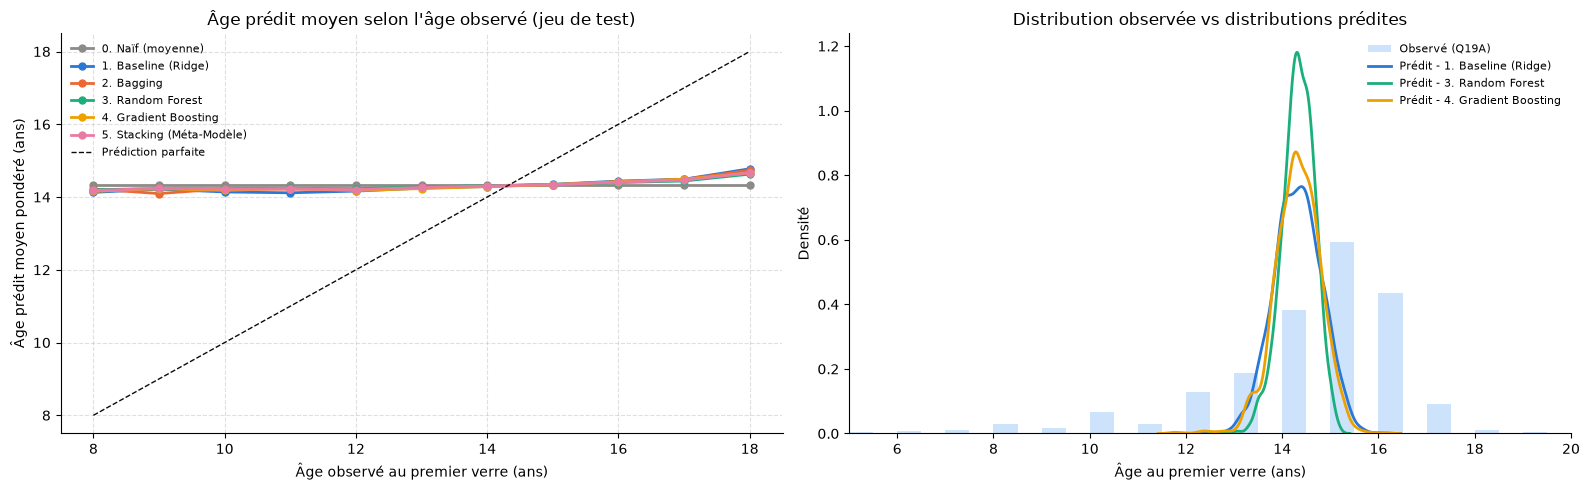

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Âge prédit moyen en fonction de l'âge observé
ages_obs = np.arange(8, 19)
for nom in ordre_modeles:
    pred = pd.Series(predictions_test[nom], index=y_test.index)
    moyennes = [
        np.average(pred[y_test == a], weights=w_test[y_test == a])
        if (y_test == a).any() else np.nan
        for a in ages_obs
    ]
    axes[0].plot(ages_obs, moyennes, marker="o", markersize=5, linewidth=2,
                 color=couleurs_modeles[nom], label=nom)
axes[0].plot(ages_obs, ages_obs, linestyle="--", color="#0b0b0b", linewidth=1,
             label="Prédiction parfaite")
axes[0].set_xlabel("Âge observé au premier verre (ans)")
axes[0].set_ylabel("Âge prédit moyen pondéré (ans)")
axes[0].set_title("Âge prédit moyen selon l'âge observé (jeu de test)")
axes[0].grid(linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8, frameon=False)

# 2. Distribution des prédictions vs distribution observée
bins = np.arange(5, 20.5, 0.5)
axes[1].hist(y_test, bins=bins, weights=w_test, density=True, color="#cde2fb",
             label="Observé (Q19A)")
for nom in ["1. Baseline (Ridge)", "3. Random Forest", "4. Gradient Boosting"]:
    sns.kdeplot(x=predictions_test[nom], weights=w_test, ax=axes[1],
                color=couleurs_modeles[nom], linewidth=2, label=f"Prédit - {nom}")
axes[1].set_xlim(5, 20)
axes[1].set_xlabel("Âge au premier verre (ans)")
axes[1].set_ylabel("Densité")
axes[1].set_title("Distribution observée vs distributions prédites")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

Le graphique de gauche montre que tous les modèles prédisent presque la même valeur, entre 14 et 15 ans, quel que soit l'âge observé : les courbes sont quasiment plates et loin de la diagonale. Les modèles ne s'écartent que très peu de la moyenne.

- Tranche 14-16 ans (70 % du jeu de test) : la MAE est inférieure à 0,9 an, mais uniquement parce que la moyenne tombe dans cette tranche. Le modèle naïf fait aussi bien.
- Initiations précoces (≤ 11 ans, 177 individus) : la MAE est d'environ 5 ans et l'âge est systématiquement surestimé d'environ 5 ans. Aucun modèle ne repère ces profils ; la Ridge fait à peine mieux que le modèle naïf (4,96 contre 5,17 ans).
- Initiations tardives (≥ 17 ans, 119 individus) : l'âge est sous-estimé d'environ 2,7 ans.

Le graphique de droite le confirme : les distributions prédites sont très resserrées (environ 13,5 à 15,5 ans) alors que les âges observés s'étalent de 5 à 20 ans. La Random Forest est la plus concentrée, puisqu'elle moyenne les prédictions de nombreux arbres.

Comme annoncé dans la partie 1, un RMSE et une MAE globaux corrects cachent donc l'incapacité des modèles à prédire les valeurs extrêmes. Les initiations précoces dépendent sans doute de facteurs absents de la base (contexte du premier verre, entourage, etc.).

### Importance des variables

On agrège l'importance des indicatrices (dummies) par variable d'origine pour la Random Forest et le Gradient Boosting (importance par réduction d'impureté). Pour la Ridge, on regarde la somme des valeurs absolues des coefficients par variable ; les indicatrices étant toutes sur la même échelle (0/1), ces coefficients sont comparables.

=== IMPORTANCE RELATIVE DES VARIABLES (%) ===
       Ridge (|coef|)  Random Forest  Gradient Boosting
B08A              6.6           12.7               16.9
Q10A1            29.9           14.5               14.5
Q10B1            12.0           13.3               12.2
Q03               4.7            8.7               11.6
B08B              7.3           11.4               11.1
Q09A1             6.2            7.3                6.7
Q05               4.4            4.9                6.1
Q08               8.1            5.1                5.6
Q09B1             6.9            6.6                5.2
Q04A              2.0            3.5                2.8
Q06B              2.8            4.2                2.7
Q06A              3.4            3.0                2.0
Q04B              4.1            1.9                1.3
Q04               1.6            2.9                1.2


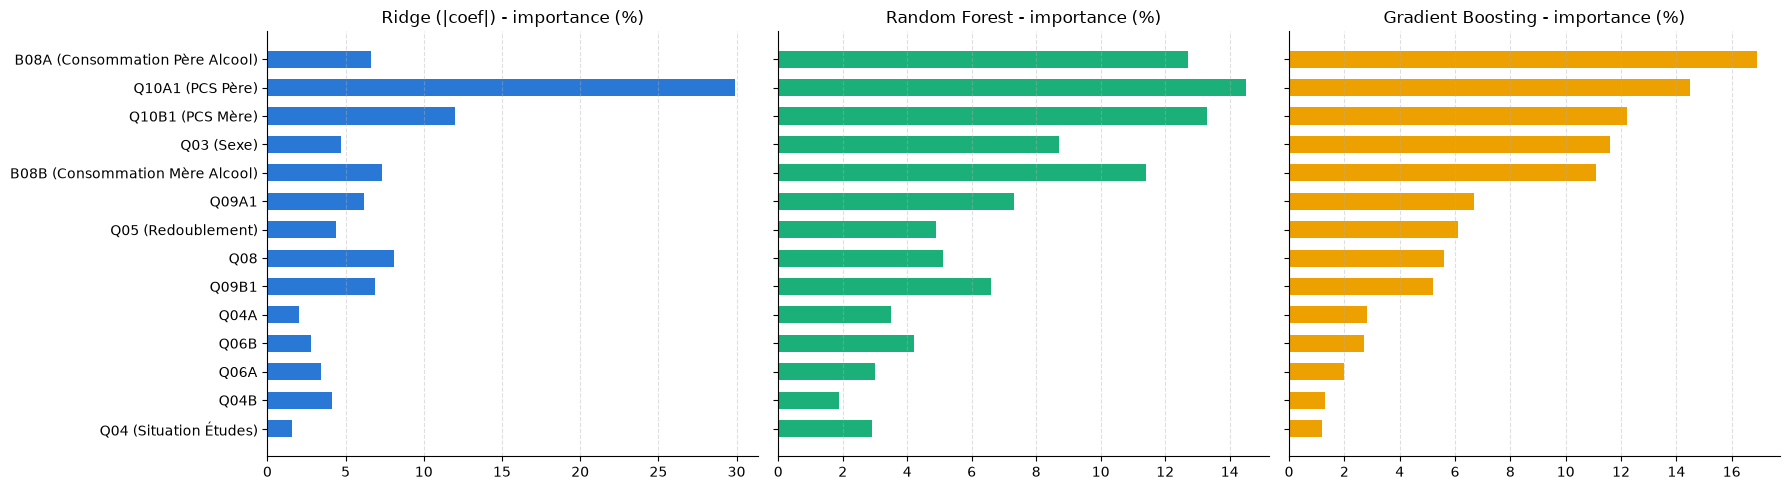

In [29]:
# Variable d'origine de chaque indicatrice (ex. "B08A_5.0" -> "B08A")
var_origine = X_train.columns.str.split("_").str[0]

importances = pd.DataFrame(
    {
        "Ridge (|coef|)": pd.Series(np.abs(ridge_model.coef_), index=X_train.columns),
        "Random Forest": pd.Series(rf_model.feature_importances_, index=X_train.columns),
        "Gradient Boosting": pd.Series(gb_model.feature_importances_, index=X_train.columns),
    }
).groupby(var_origine).sum()

# Normalisation en % pour comparer les trois modèles
importances = (importances / importances.sum() * 100).round(1)
importances = importances.sort_values("Gradient Boosting", ascending=False)
etiquettes = [
    f"{v} ({labels_dict[v]})" if v in labels_dict else v for v in importances.index
]

print("=== IMPORTANCE RELATIVE DES VARIABLES (%) ===")
print(importances.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (col, nom) in zip(
    axes,
    [
        ("Ridge (|coef|)", "1. Baseline (Ridge)"),
        ("Random Forest", "3. Random Forest"),
        ("Gradient Boosting", "4. Gradient Boosting"),
    ],
):
    ax.barh(etiquettes, importances[col], color=couleurs_modeles[nom], height=0.6)
    ax.set_title(f"{col} - importance (%)")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

Les trois modèles s'accordent sur les variables principales : la consommation d'alcool des parents (B08A, B08B), la PCS des parents (Q10A1, Q10B1) et le sexe (Q03). Cela confirme l'analyse bivariée de la partie 1. Le redoublement (Q05), pourtant très significatif dans l'ANOVA (F = 35,7), n'a qu'une importance moyenne (4 à 6 %) : une fois les autres variables prises en compte, il apporte peu d'information supplémentaire.

Les variables de scolarité (Q04, Q04A, Q04B) pèsent peu, ce qui est cohérent avec leur forte redondance mise en évidence par le V de Cramér.

Deux précautions de lecture :
- pour la Ridge, la somme des |coefficients| favorise les variables qui ont beaucoup de modalités : c'est pourquoi la PCS du père (9 modalités + Manquant) atteint 30 % ;
- l'importance par réduction d'impureté des arbres favorise aussi les variables à nombreuses modalités. Une importance par permutation sur le jeu de test serait plus robuste.

## 4 - Conclusion

L'objectif de ce projet était de prédire l'âge au premier verre d'alcool (Q19A) à partir des réponses au tronc commun et au module B de l'enquête ESCAPAD 2017, en comparant plusieurs méthodes d'agrégation de modèles.

Données : Après nettoyage, 10 874 jeunes ont été conservés : ceux qui déclarent un âge au premier verre compris entre 5 et 20 ans. Les jeunes sans réponse à Q19A, probablement en grande partie des non-buveurs, sont exclus : nos résultats portent donc uniquement sur les jeunes ayant déjà bu de l'alcool. La cible est très concentrée (71 % des âges entre 14 et 16 ans, écart-type pondéré de 1,97 an), ce qui laisse peu de variance à expliquer.

Facteurs associés :  L'analyse descriptive et les modèles donnent le même constat. Les jeunes boivent leur premier verre plus tôt lorsque leurs parents consomment régulièrement de l'alcool (environ 0,8 an d'écart entre une consommation quotidienne et une consommation nulle), et les garçons commencent plus tôt que les filles (14,10 ans contre 14,55 ans en moyenne pondérée). La PCS des parents fait aussi partie des variables les plus importantes. La scolarité (redoublement, situation d'études) joue un rôle plus modeste.

Comparaison des modèles : Les méthodes d'agrégation n'apportent aucun gain par rapport à la régression Ridge, qui reste le meilleur modèle (RMSE test de 2,005 ans, R² de 3,6 %). La Random Forest, le Stacking et le Gradient Boosting obtiennent des résultats très proches de la Ridge, un peu en dessous. Le Bagging est le moins bon et celui qui surapprend le plus. Tous les modèles ne font qu'à peine mieux que la prédiction constante de l'âge moyen (au mieux 1,9 % de RMSE en moins). Les effets des prédicteurs semblent essentiellement additifs, et les arbres ne trouvent pas d'interactions qui amélioreraient la prédiction.

Limites : Les modèles prédisent presque toujours un âge entre 14 et 15 ans. Ils se trompent donc fortement sur les initiations précoces (erreur d'environ 5 ans pour les 11 ans et moins) et sur les initiations tardives (environ 2,7 ans pour les 17 ans et plus). Les variables disponibles, qui décrivent surtout la situation familiale et scolaire, ne suffisent pas à expliquer l'âge au premier verre, qui dépend sans doute de facteurs non observés ici (contexte du premier verre, amis, lieu de vie, etc.). Par ailleurs, les hyperparamètres des modèles d'ensemble ont été fixés sans optimisation.

Pistes d'amélioration :
- Optimiser les hyperparamètres par validation croisée (profondeur des arbres, nombre d'estimateurs, taux d'apprentissage, pénalité de la Ridge).
- Coder les variables ordinales (fréquence de consommation des parents) en numérique plutôt qu'en indicatrices.
- Traiter les non-réponses à Q19A, par exemple en modélisant d'abord le fait d'avoir déjà bu.
- Reformuler le problème en classification (initiation précoce ou non), plus utile en prévention que la prédiction d'un âge exact.
- Mesurer l'importance des variables par permutation, plus robuste que l'importance par impureté.